<a href="https://colab.research.google.com/github/Fathima-Rinsha-k/RNN/blob/main/GEO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<Axes: >

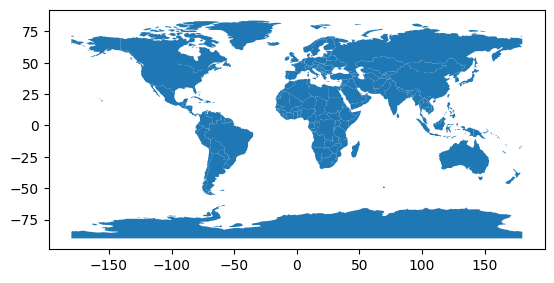

In [ ]:
import geopandas as gpd

url = "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"

world = gpd.read_file(url)

world.plot()


In [ ]:
!pip install osmnx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.5/101.5 kB 2.6 MB/s eta 0:00:00


<Axes: >

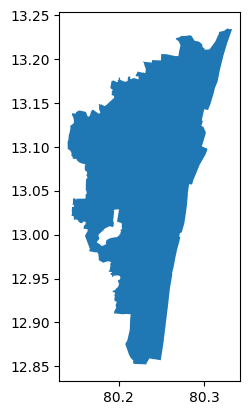

In [ ]:
import osmnx as ox

gdf = ox.geocode_to_gdf("CHENNAI, India")

gdf.plot()

In [ ]:
# View first rows
print(gdf.head())

# CRS (coordinate system)
print(gdf.crs)

# Geometry type
print(gdf.geometry.type)

# Columns
print(gdf.columns)

                                            geometry  bbox_west  bbox_south  \
0  POLYGON ((80.14019 13.10571, 80.1404 13.09789,...  80.140187   12.851977   

   bbox_east  bbox_north   place_id  osm_type   osm_id        lat        lon  \
0  80.332898   13.235158  419050126  relation  1766358  13.083694  80.270186   

      class            type  place_rank  importance addresstype     name  \
0  boundary  administrative          16    0.679607        city  Chennai   

                 display_name  
0  Chennai, Tamil Nadu, India  
epsg:4326
0    Polygon
dtype: object
Index(['geometry', 'bbox_west', 'bbox_south', 'bbox_east', 'bbox_north',
       'place_id', 'osm_type', 'osm_id', 'lat', 'lon', 'class', 'type',
       'place_rank', 'importance', 'addresstype', 'name', 'display_name'],
      dtype='object')


In [ ]:
# Project to UTM (meters)
gdf_proj = gdf.to_crs(epsg=32643)   # UTM zone for Delhi

# Area (in sq km)
gdf_proj["area_sqkm"] = gdf_proj.area / 1e6

# Perimeter (in km)
gdf_proj["perimeter_km"] = gdf_proj.length / 1000

print(gdf_proj[["area_sqkm", "perimeter_km"]])

    area_sqkm  perimeter_km
0  434.541836    149.642006


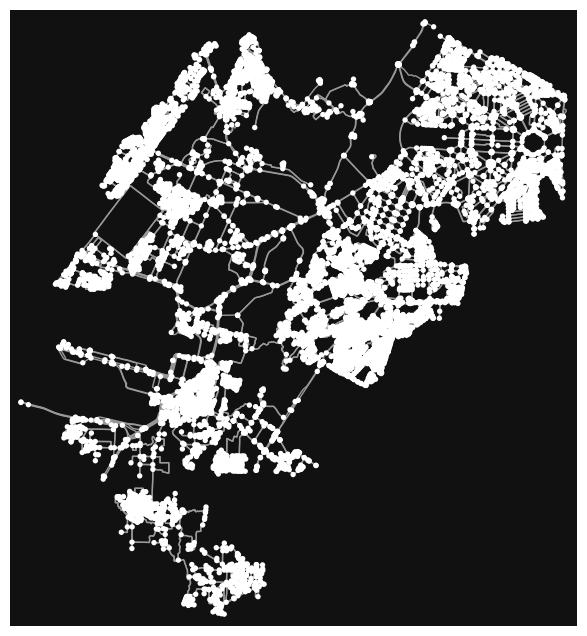

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [ ]:
# Download road network
G = ox.graph_from_place("Delhi, India", network_type="drive")

# Plot roads
ox.plot_graph(G)


In [ ]:
stats = ox.basic_stats(G)

for k, v in stats.items():
    print(k, ":", v)

n : 10116
m : 24311
k_avg : 4.806445235270858
edge_length_total : 2182135.5043085245
edge_length_avg : 89.75918326307122
streets_per_node_avg : 2.8189996045867933
streets_per_node_counts : {0: 0, 1: 1533, 2: 25, 3: 7307, 4: 1242, 5: 9}
streets_per_node_proportions : {0: 0.0, 1: 0.15154211150652433, 2: 0.0024713325425069197, 3: 0.7223210755239226, 4: 0.12277580071174377, 5: 0.0008896797153024911}
intersection_count : 8583
street_length_total : 1377269.7005442218
street_segment_count : 14143
street_length_avg : 97.38172244532431
circuity_avg : 1.0643240786760932
self_loop_proportion : 0.0007777699215159443


Number of buildings: 48129


<Axes: >

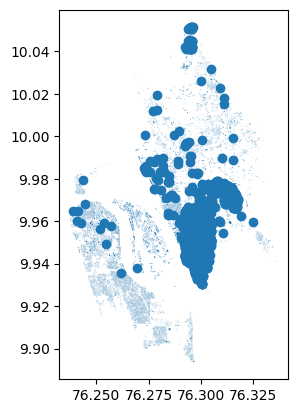

In [ ]:
from shapely.geometry import Polygon

# Get polygon
polygon = gdf.geometry.iloc[0]

# Download buildings
buildings = ox.features_from_polygon(
    polygon,
    tags={"building": True}
)

print("Number of buildings:", len(buildings))

buildings.plot()


In [ ]:
area = gdf_proj["area_sqkm"].iloc[0]

density = len(buildings) / area

print("Building Density per sq km:", density)

Building Density per sq km: 484.2894056009074


/tmp/ipython-input-3711730060.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["centroid"] = buildings.centroid


<Axes: >

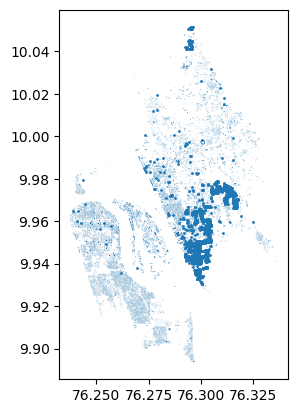

In [ ]:
# Count buildings per ward (if available)
buildings["centroid"] = buildings.centroid

buildings.plot(markersize=1)

In [ ]:
landuse = ox.features_from_polygon(
    polygon,
    tags={"landuse": True}
)

landuse["landuse"].value_counts()

,count
landuse,
residential,405
commercial,96
industrial,43
religious,38
grass,36
recreation_ground,34
education,27
cemetery,24
farmland,17


<Axes: >

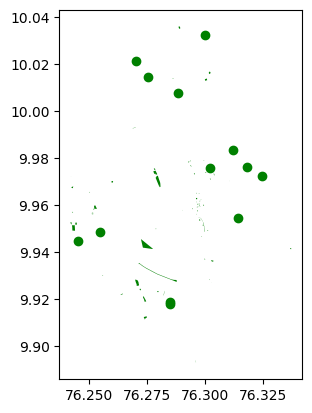

In [ ]:
green = ox.features_from_polygon(
    polygon,
    tags={"leisure": "park"}
)

green.plot(color="green")

In [ ]:
print("Number of parks:", len(green))

Number of parks: 83


In [ ]:
# Save buildings
buildings_to_save = buildings.drop(columns=['centroid'])
buildings_to_save.to_file("delhi_buildings.geojson", driver="GeoJSON")

# Save roads
ox.save_graphml(G, "delhi_roads.graphml")

In [ ]:
# Convert geometry to centroids
buildings["centroid"] = buildings.geometry.centroid

# Extract lat/lon
buildings["lat"] = buildings.centroid.y
buildings["lon"] = buildings.centroid.x

/tmp/ipython-input-3882717123.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["centroid"] = buildings.geometry.centroid
/tmp/ipython-input-3882717123.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["lat"] = buildings.centroid.y
/tmp/ipython-input-3882717123.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buildings["lon"] = buildings.centroid.x


In [ ]:
buildings_tabular = buildings.drop(columns=["geometry", "centroid"])

In [ ]:
buildings_tabular.to_excel("delhi_buildings.xlsx", index=False)


In [ ]:
from google.colab import files
files.download("delhi_buildings.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>